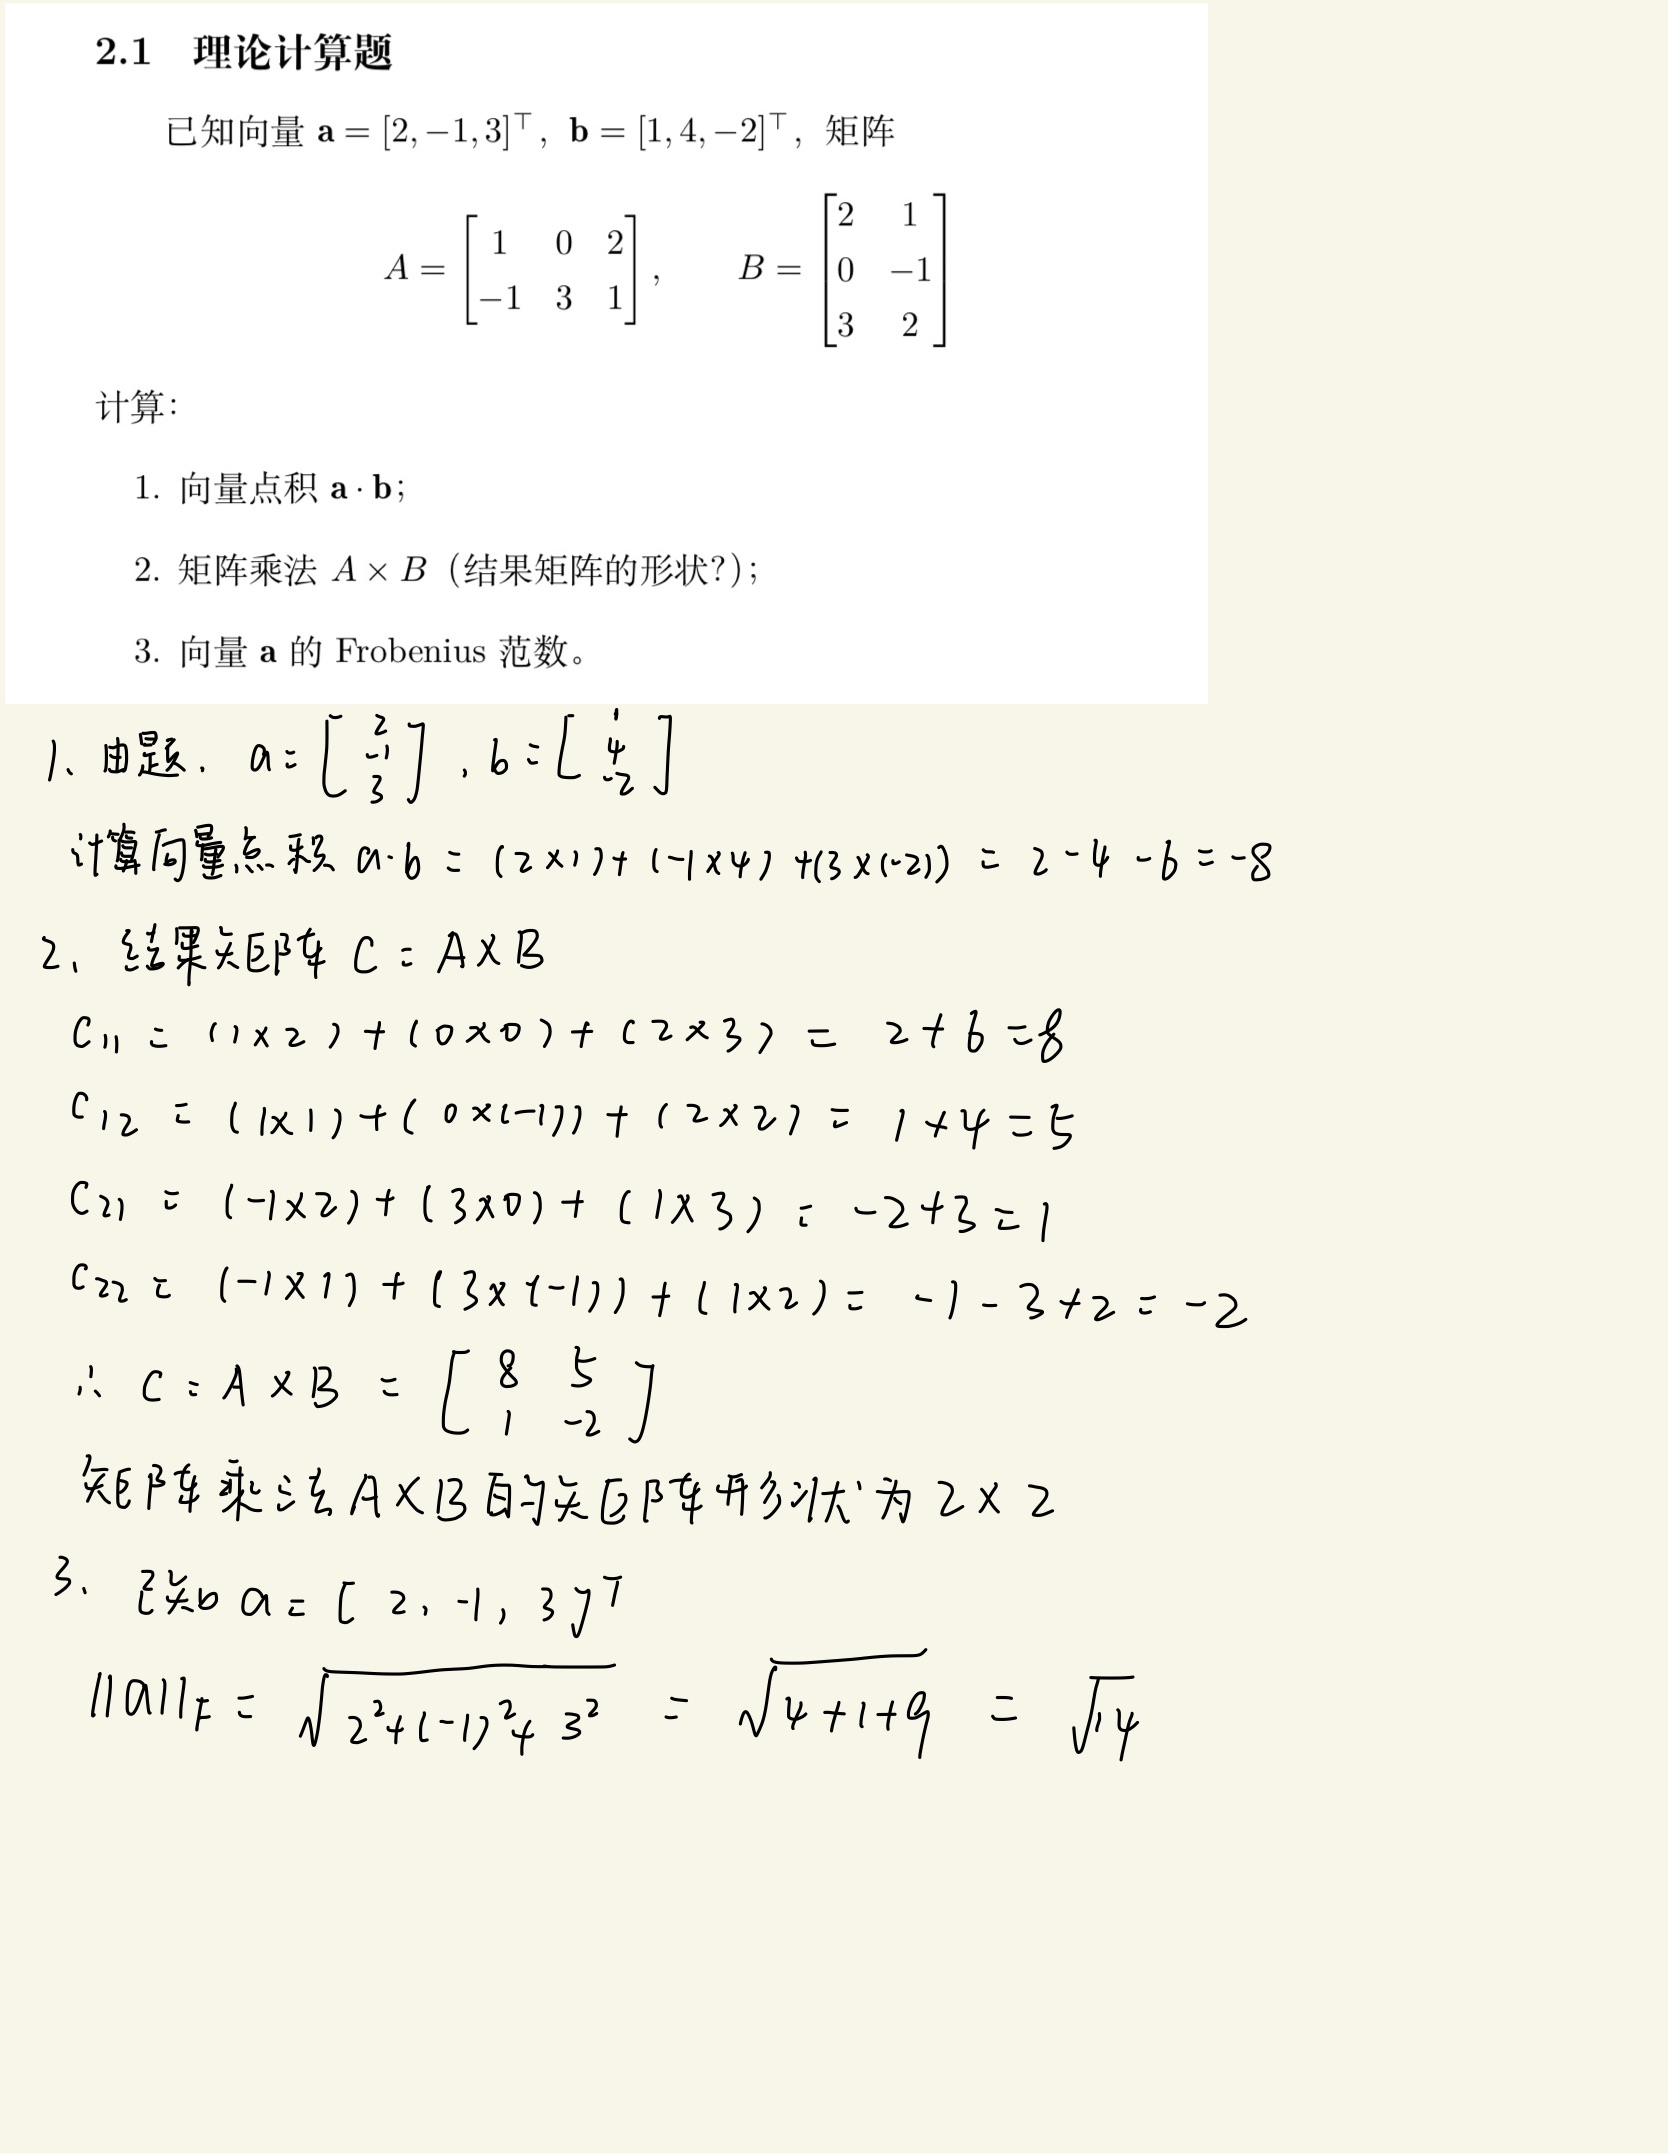

In [1]:
import numpy as np

# 1. 创建形状为 3x4 的随机矩阵 X，元素服从标准正态分布
np.random.seed(42)  # 固定随机种子以便复现
X = np.random.randn(3, 4)
print("X:\n", X)

# 2. 创建形状为 4x2 的全1矩阵 Y
Y = np.ones((4, 2))
print("Y:\n", Y)

# 3. 计算矩阵乘法 Z = X @ Y
Z = X @ Y
print("Z (3x2):\n", Z)

# 4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第2行所有元素
print("Z[0, 1] =", Z[0, 1])   # 第一行第二列（索引从0开始）
print("Z的第2行（索引1）:", Z[1, :])

# 5. 计算 Z 的 Frobenius 范数
frob_norm = np.linalg.norm(Z, 'fro')
print("Z的Frobenius范数:", frob_norm)

X:
 [[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]
Y:
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
Z (3x2):
 [[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]
Z[0, 1] = 2.5291682463487657
Z的第2行（索引1）: [1.87835721 1.87835721]
Z的Frobenius范数: 4.616873319476863


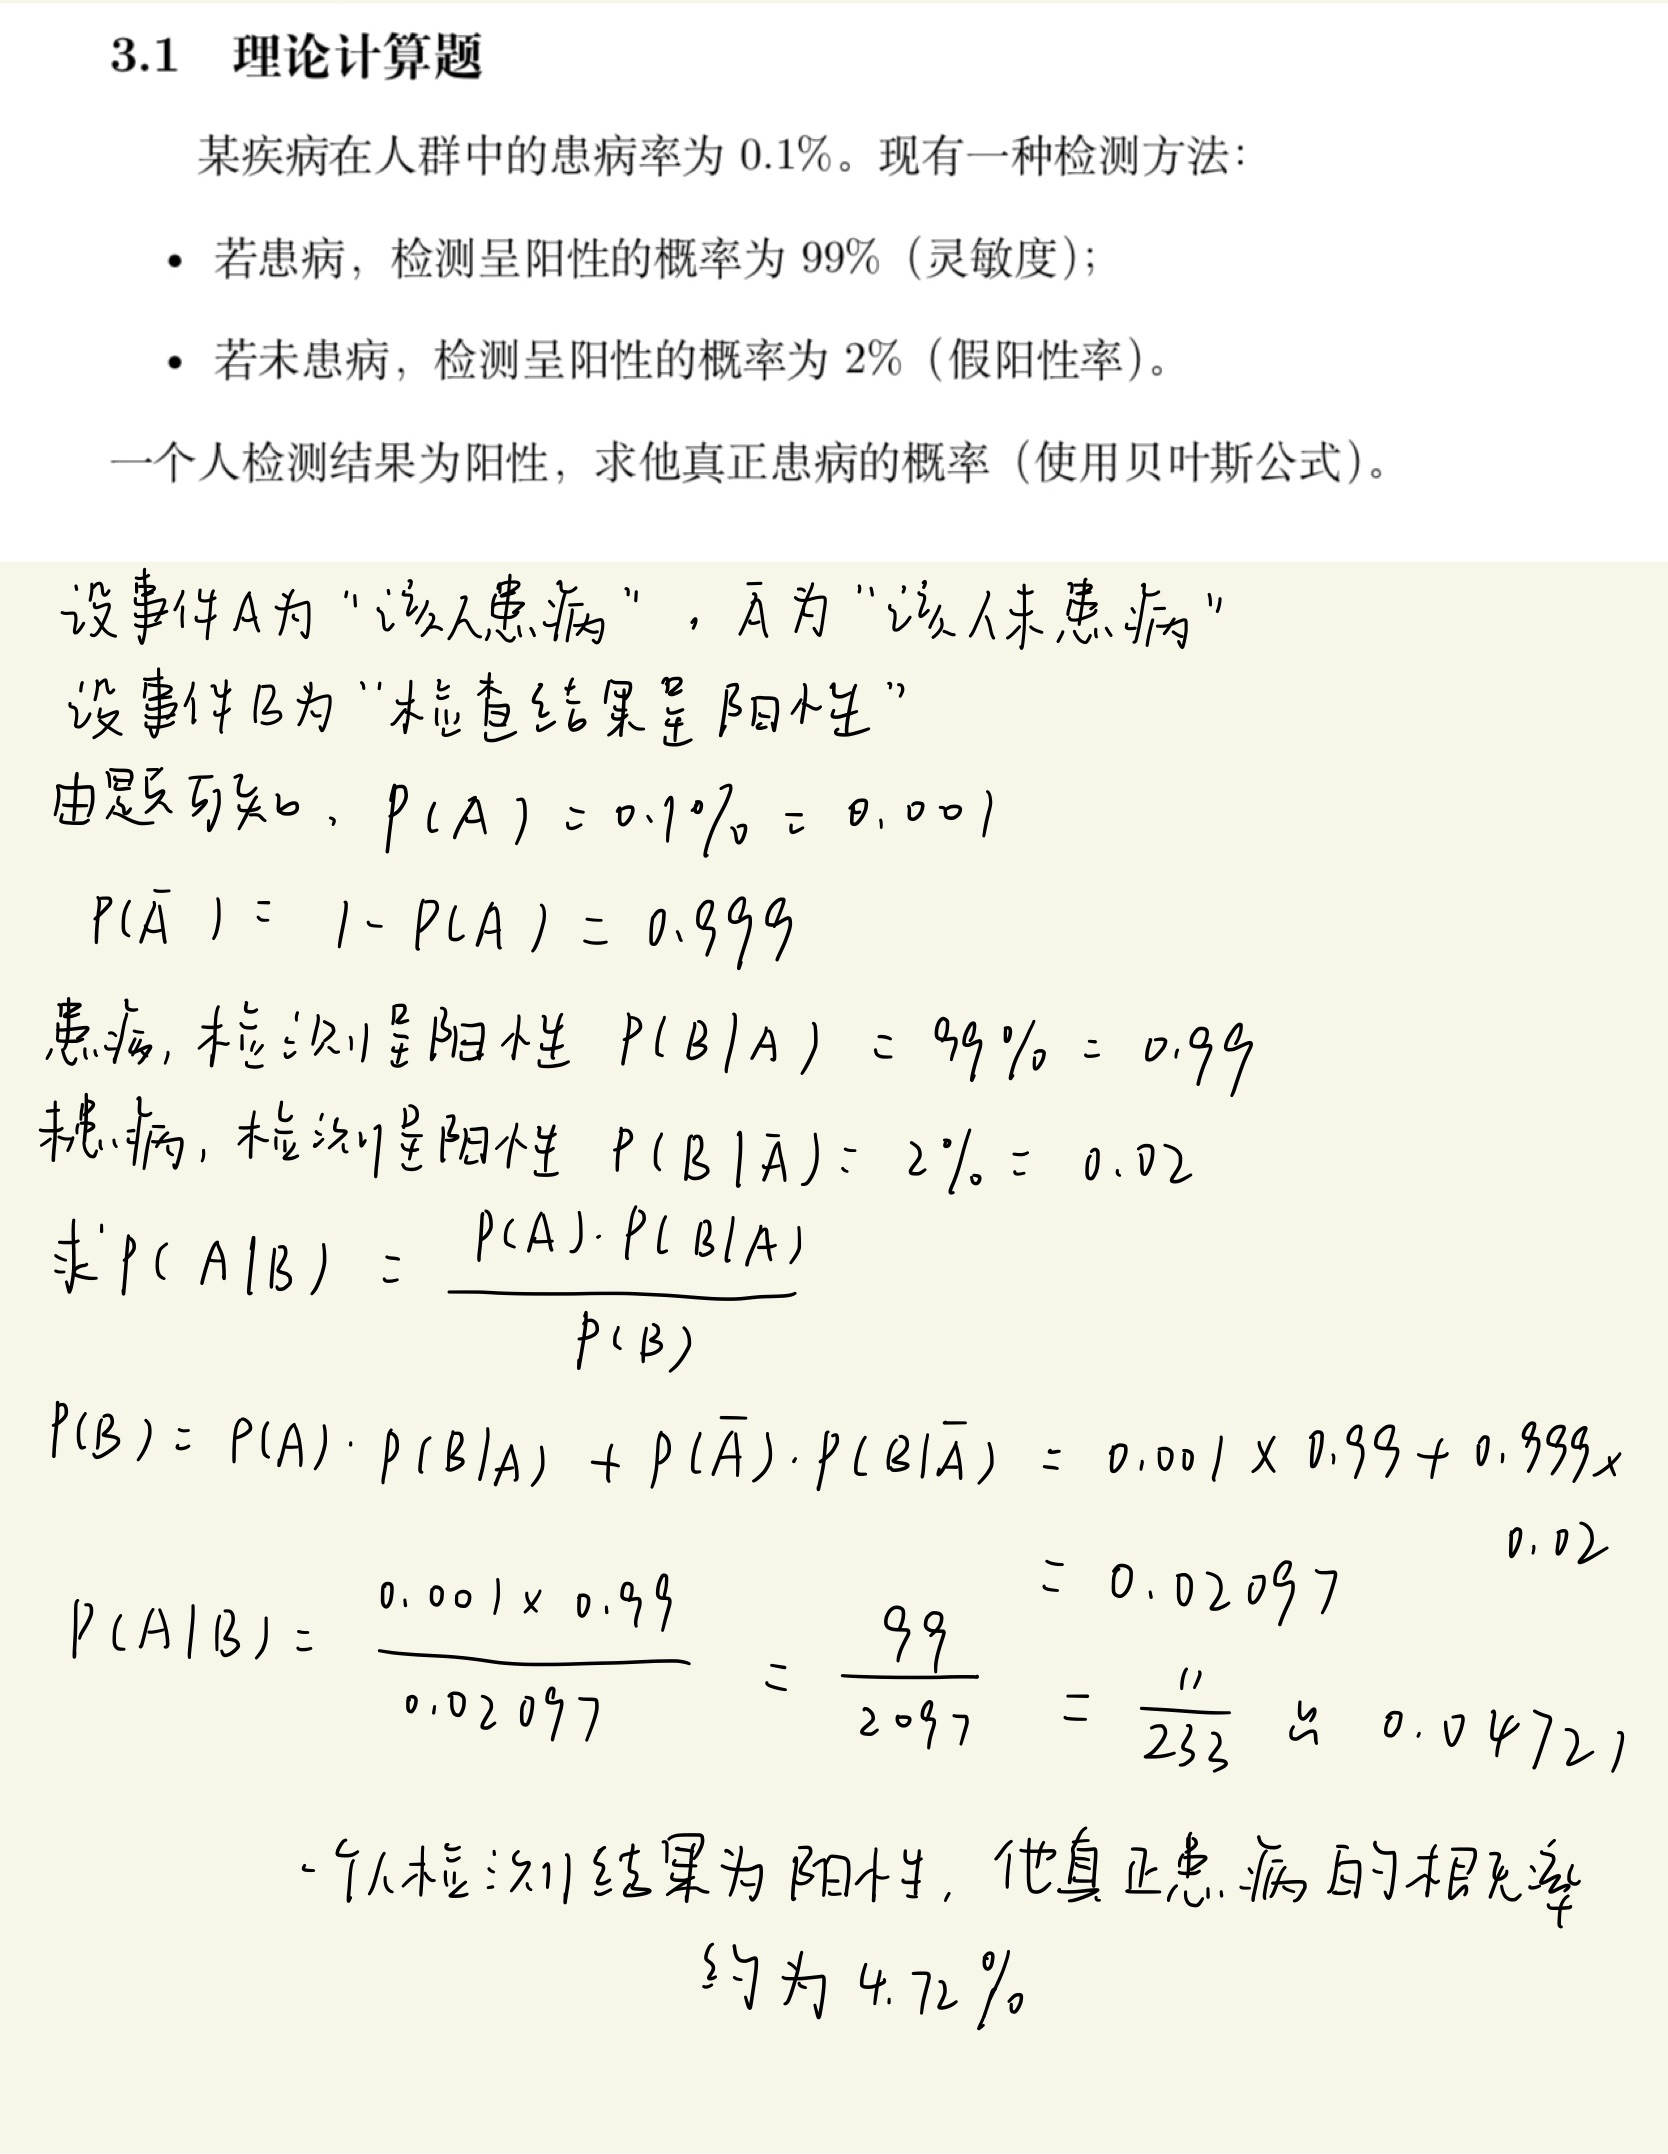

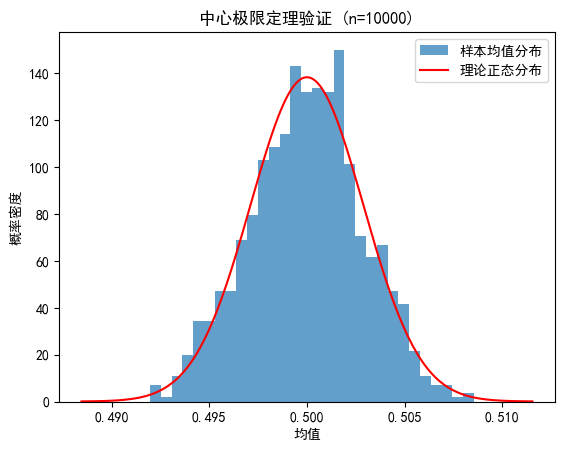

实际方差: 0.000008
理论方差: 0.000008


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体（Windows 常见）
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示异常

n = 10000   # 每个样本的容量
m = 1000    # 重复次数

# 生成 m 组，每组 n 个 U(0,1) 随机数，计算每组均值
means = np.mean(np.random.uniform(0, 1, (m, n)), axis=1)

# 理论：均值的均值 = 0.5，方差 = (1/12)/n = 1/(12n)
mu_theory = 0.5
var_theory = 1 / (12 * n)
sigma_theory = np.sqrt(var_theory)

# 绘制直方图
plt.hist(means, bins=30, density=True, alpha=0.7, label='样本均值分布')
x = np.linspace(mu_theory - 4*sigma_theory, mu_theory + 4*sigma_theory, 200)
plt.plot(x, norm.pdf(x, mu_theory, sigma_theory), 'r-', label='理论正态分布')
plt.xlabel('均值')
plt.ylabel('概率密度')
plt.title('中心极限定理验证 (n=10000)')
plt.legend()
plt.show()

# 计算实际方差
actual_var = np.var(means)
print(f"实际方差: {actual_var:.6f}")
print(f"理论方差: {var_theory:.6f}")

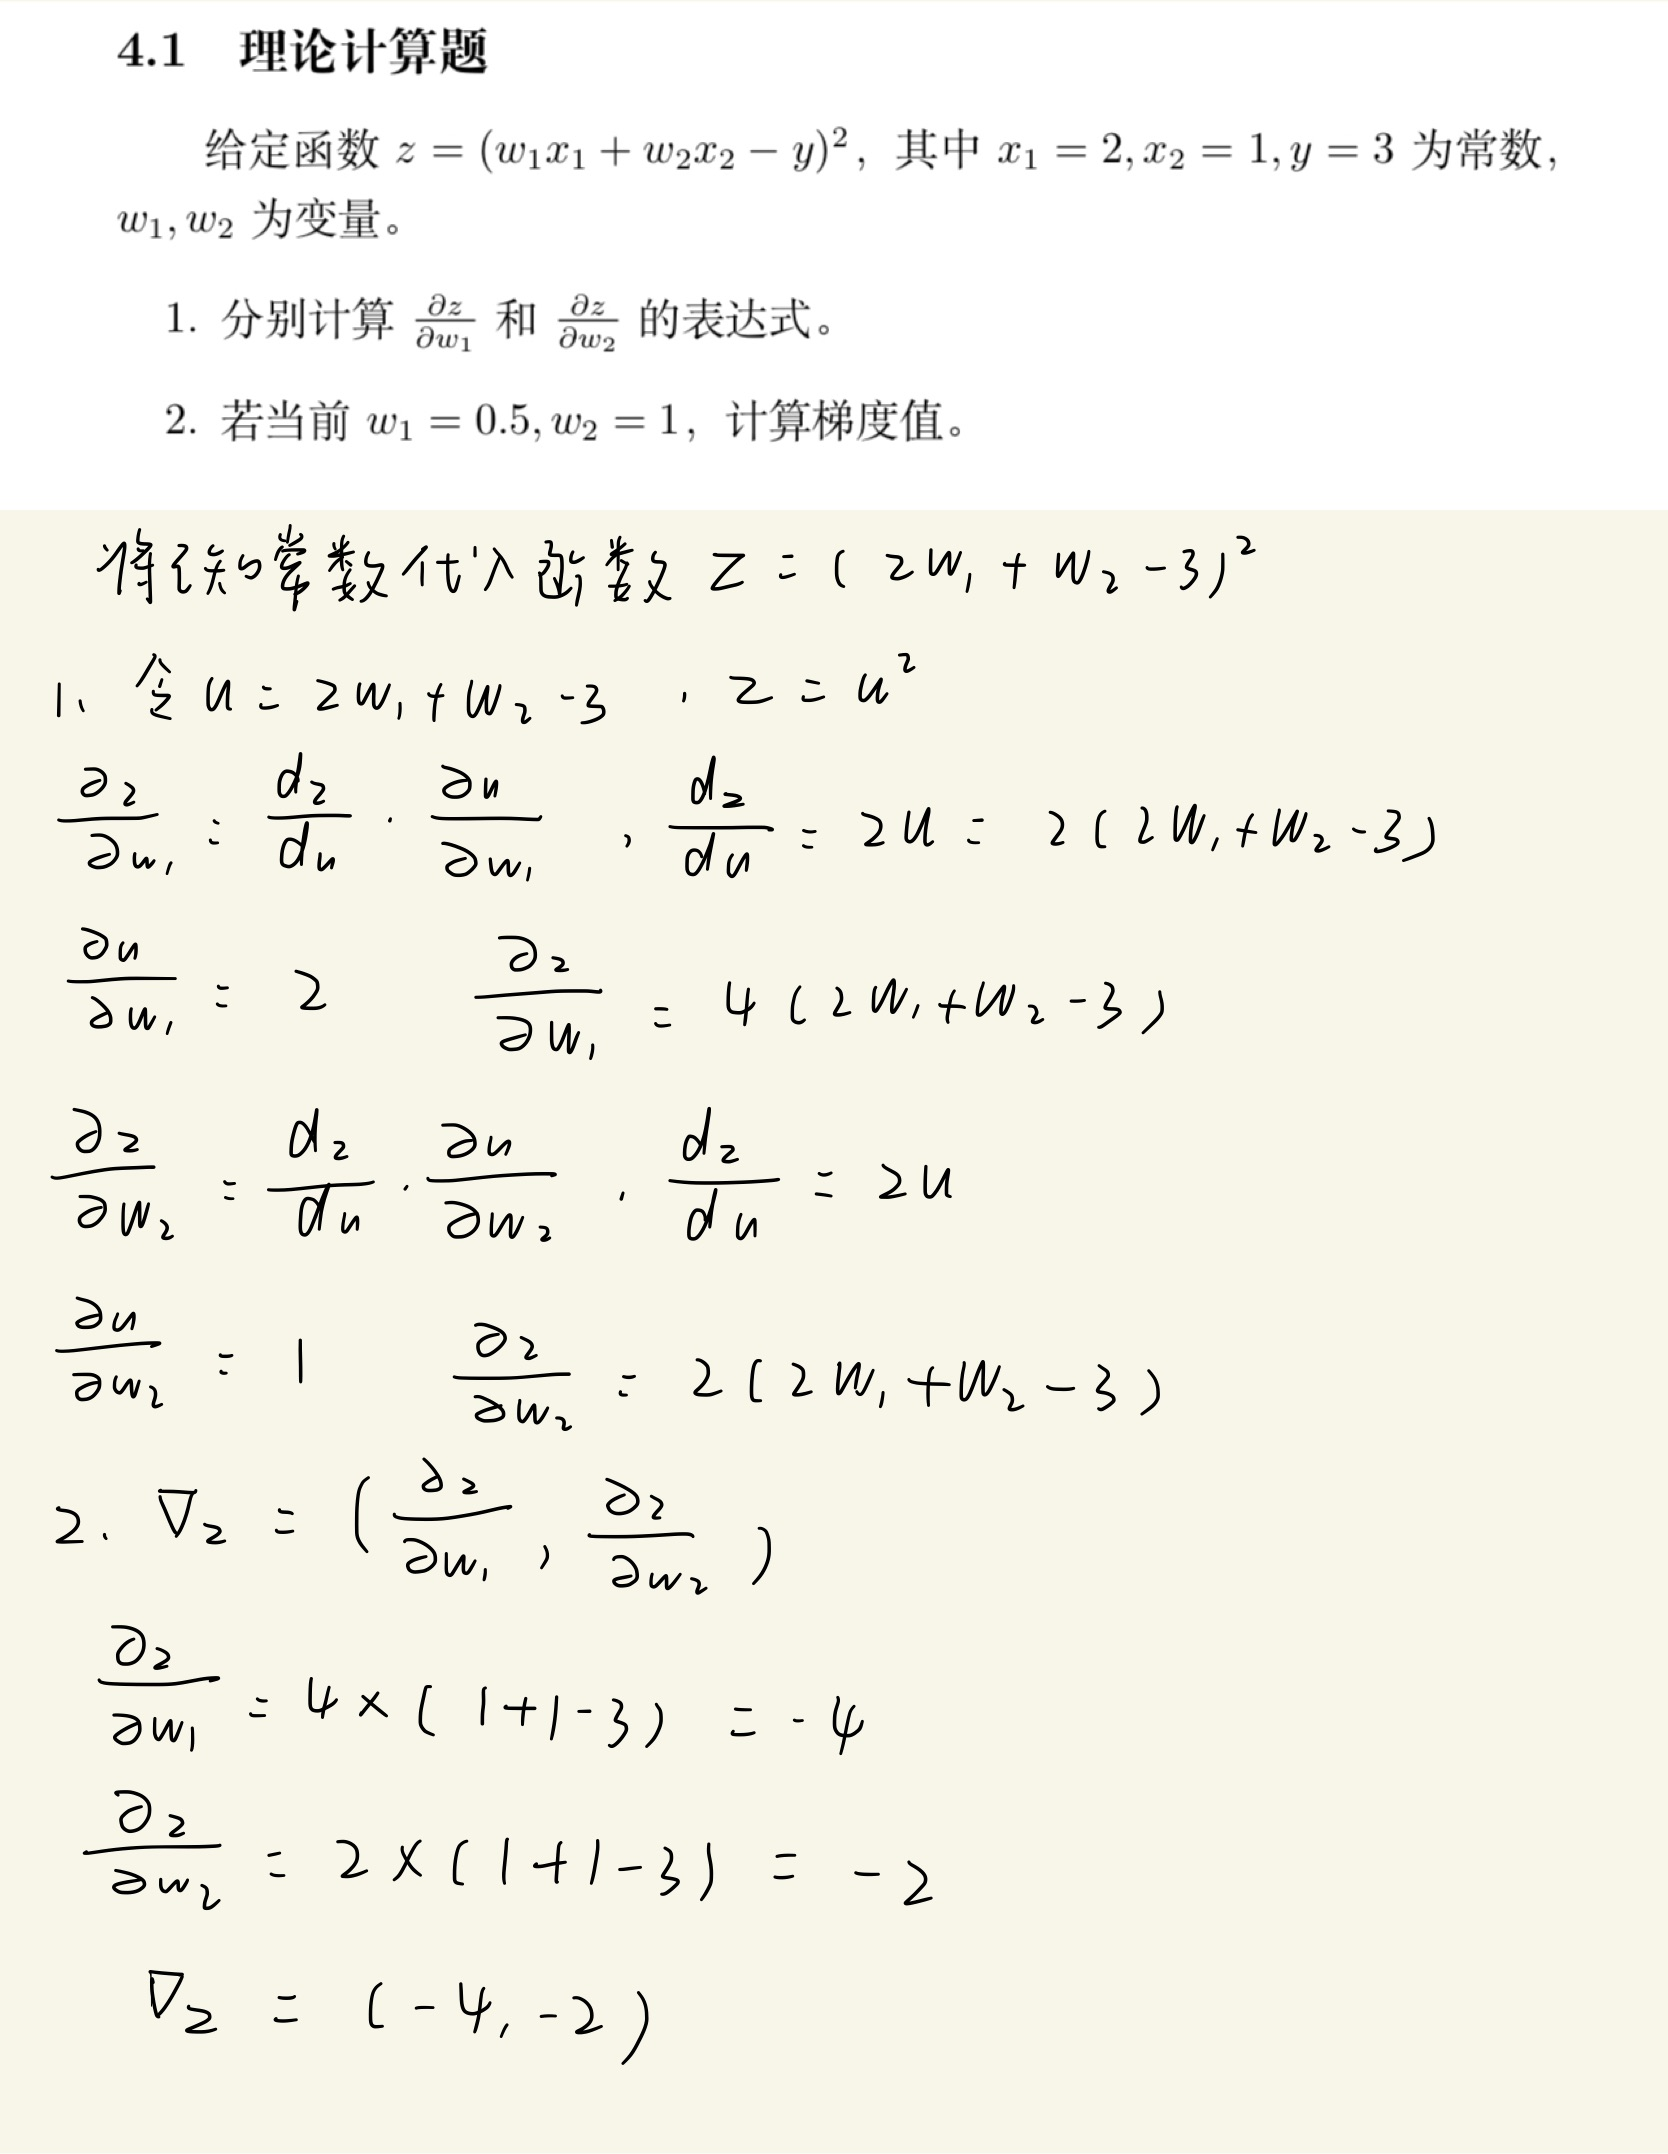

In [3]:
import torch

# 前向计算：a = x * w1, b = a + w2, L = b^2
x, w1, w2 = 2.0, 1.5, 0.5
a = x * w1
b = a + w2
L = b ** 2
print(f"前向结果 L = {L}")

# 手动求导（链式法则）
# dL/db = 2b
# db/da = 1, db/dw2 = 1
# da/dw1 = x
# 因此：
# dL/dw1 = dL/db * db/da * da/dw1 = 2b * 1 * x = 2 * (x*w1 + w2) * x
# dL/dw2 = dL/db * db/dw2 = 2b * 1 = 2*(x*w1 + w2)
b_val = x*w1 + w2
grad_w1_manual = 2 * b_val * x
grad_w2_manual = 2 * b_val
print(f"手动梯度: dw1 = {grad_w1_manual}, dw2 = {grad_w2_manual}")

# 使用 PyTorch 自动微分验证
w1_t = torch.tensor(w1, requires_grad=True)
w2_t = torch.tensor(w2, requires_grad=True)
x_t = torch.tensor(x)
a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2
L_t.backward()
print(f"PyTorch梯度: dw1 = {w1_t.grad.item()}, dw2 = {w2_t.grad.item()}")

前向结果 L = 12.25
手动梯度: dw1 = 14.0, dw2 = 7.0
PyTorch梯度: dw1 = 14.0, dw2 = 7.0


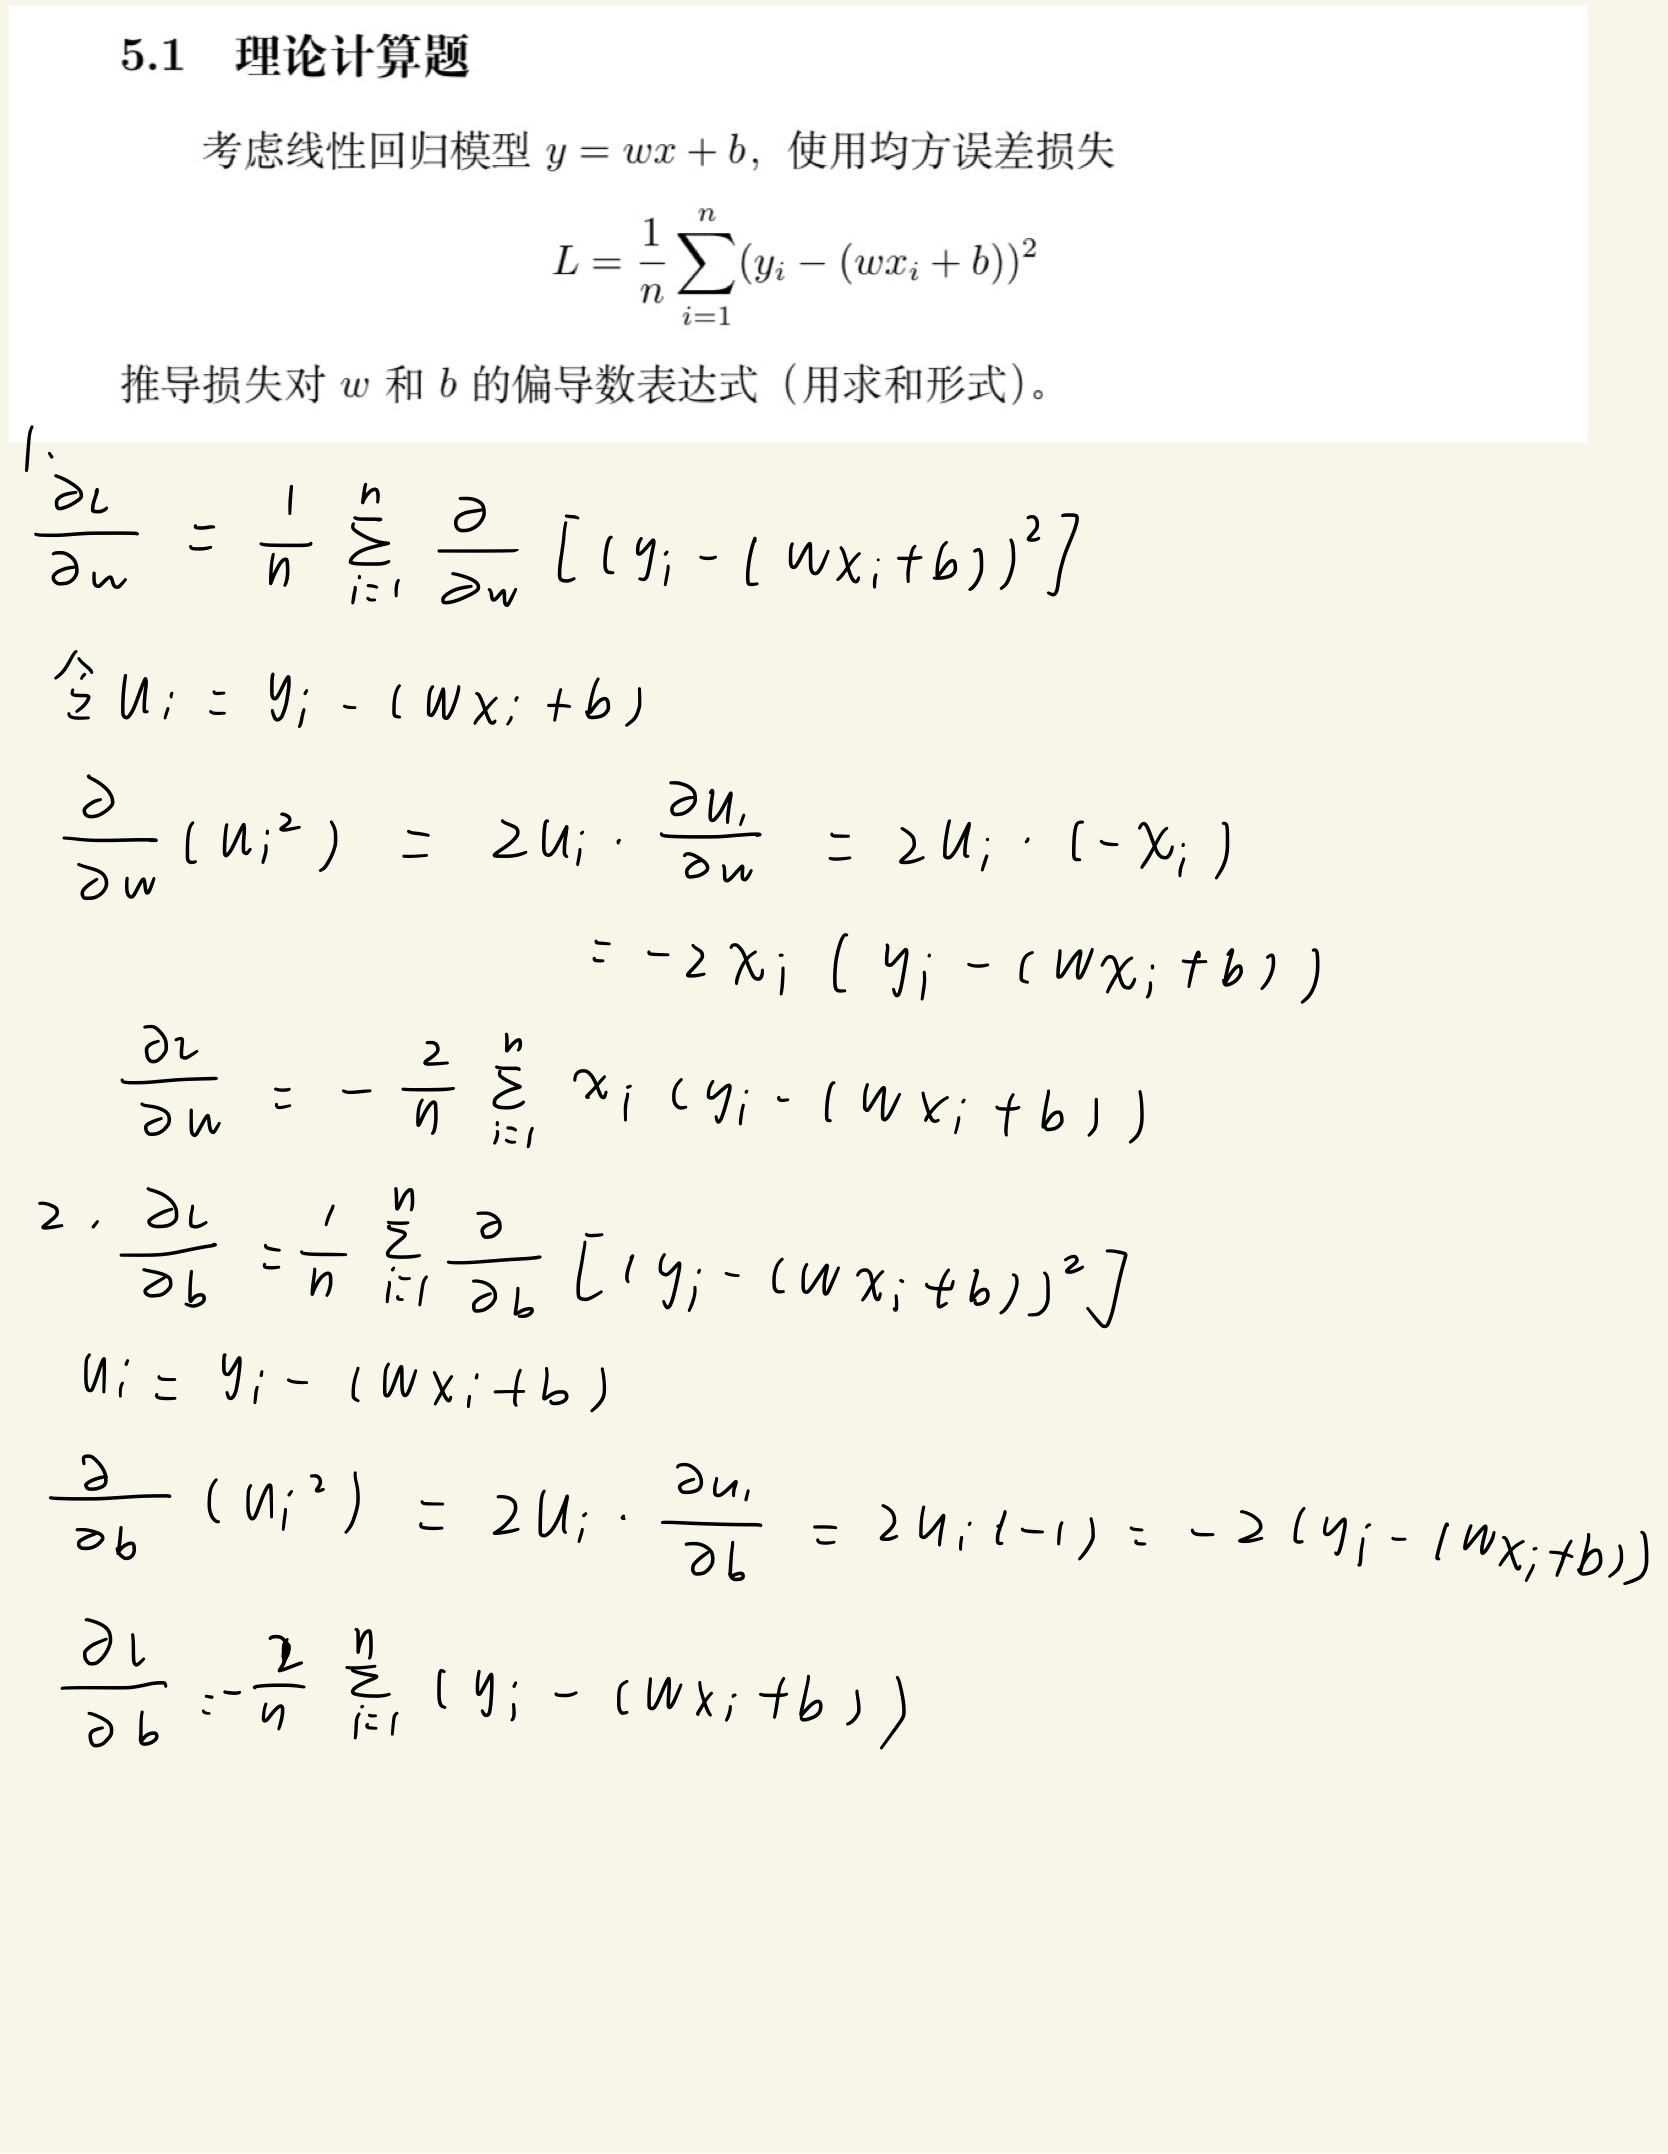

In [4]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 加载数据
digits = load_digits()
X = digits.data  # (1797, 64)
y = digits.target.reshape(-1, 1)

# 归一化
X = X / 16.0

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# One-hot 编码标签
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train)
y_test_onehot = encoder.transform(y_test)

# 参数初始化
input_dim = X_train.shape[1]   # 64
num_classes = 10
W = np.random.randn(input_dim, num_classes) * 0.01
b = np.zeros((1, num_classes))

# Softmax 函数
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# 交叉熵损失
def cross_entropy_loss(y_pred, y_true):
    n = y_true.shape[0]
    loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / n
    return loss

# 训练参数
lr = 0.1
batch_size = 32
epochs = 50
n_samples = X_train.shape[0]

for epoch in range(epochs):
    # 随机打乱
    indices = np.random.permutation(n_samples)
    X_shuffled = X_train[indices]
    y_shuffled = y_train_onehot[indices]
    
    for i in range(0, n_samples, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        # 前向传播
        logits = X_batch @ W + b
        probs = softmax(logits)
        
        # 损失
        loss = cross_entropy_loss(probs, y_batch)
        
        # 反向传播
        grad_logits = probs - y_batch   # (batch, 10)
        grad_W = X_batch.T @ grad_logits / batch_size
        grad_b = np.mean(grad_logits, axis=0, keepdims=True)
        
        # 参数更新
        W -= lr * grad_W
        b -= lr * grad_b
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, loss = {loss:.4f}")

# 测试准确率
logits_test = X_test @ W + b
probs_test = softmax(logits_test)
y_pred = np.argmax(probs_test, axis=1)
y_true = y_test.flatten()
accuracy = np.mean(y_pred == y_true)
print(f"测试集准确率: {accuracy:.4f}")

Epoch 10, loss = 0.4614
Epoch 20, loss = 0.2944
Epoch 30, loss = 0.2335
Epoch 40, loss = 0.1405
Epoch 50, loss = 0.1924
测试集准确率: 0.9639


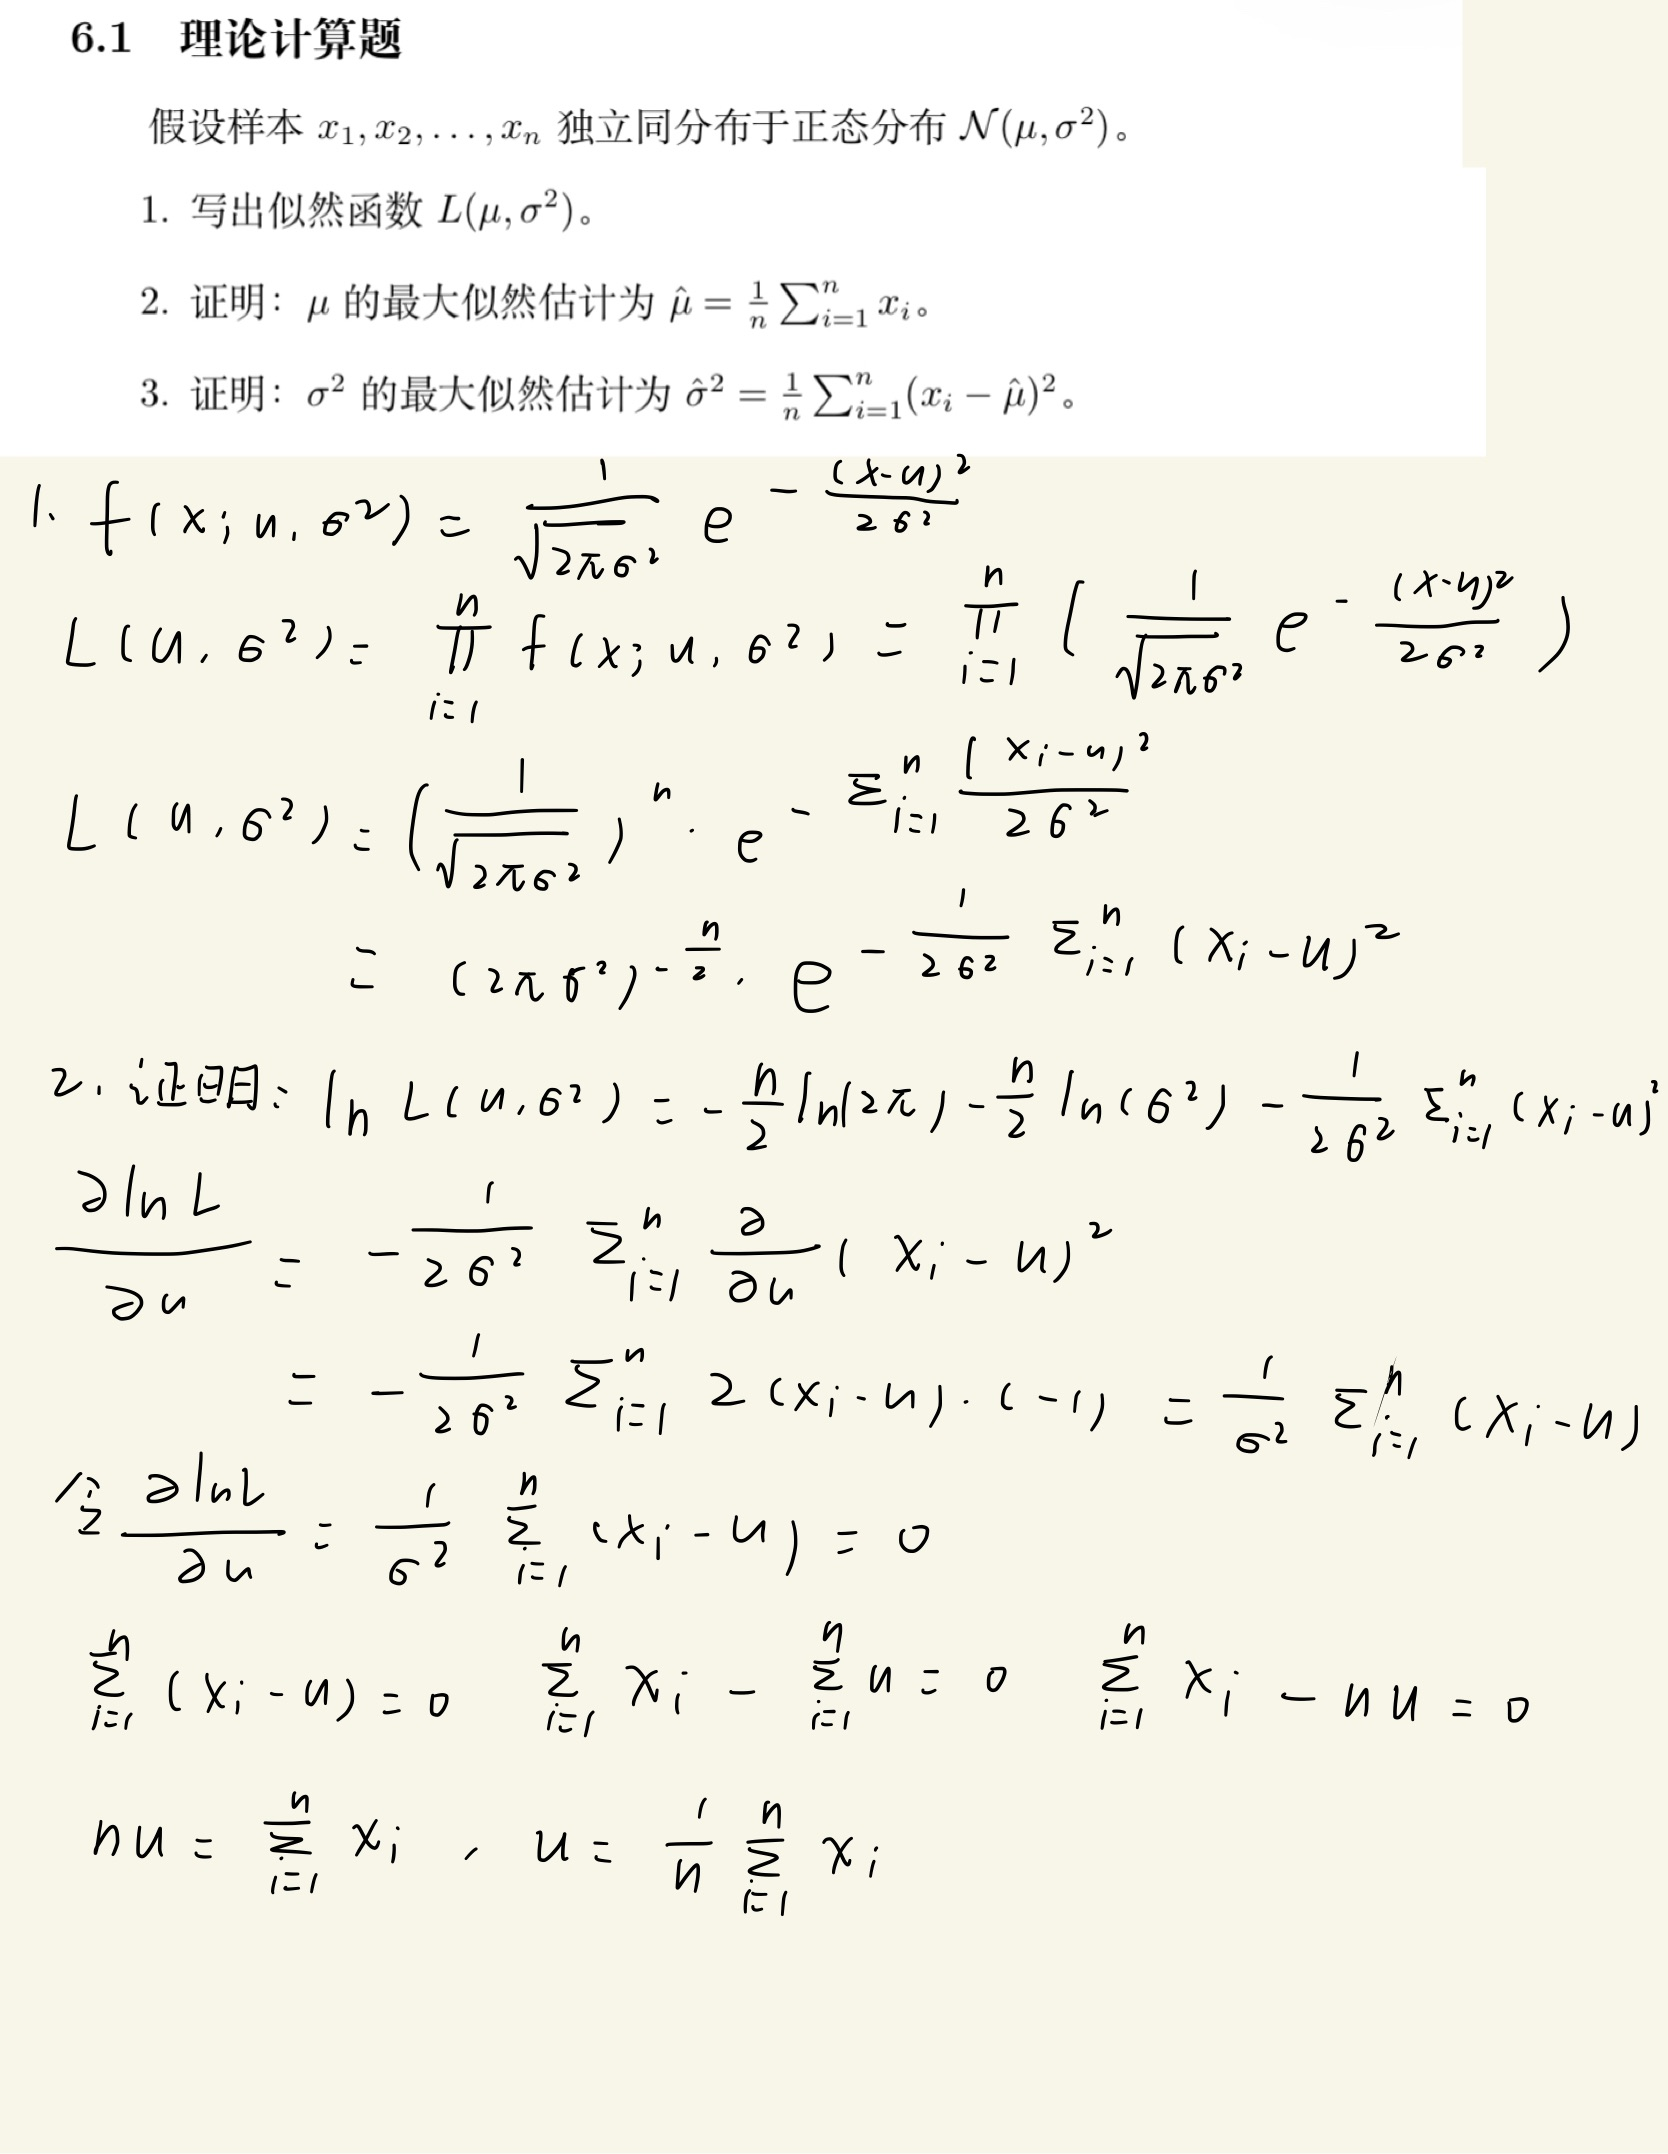

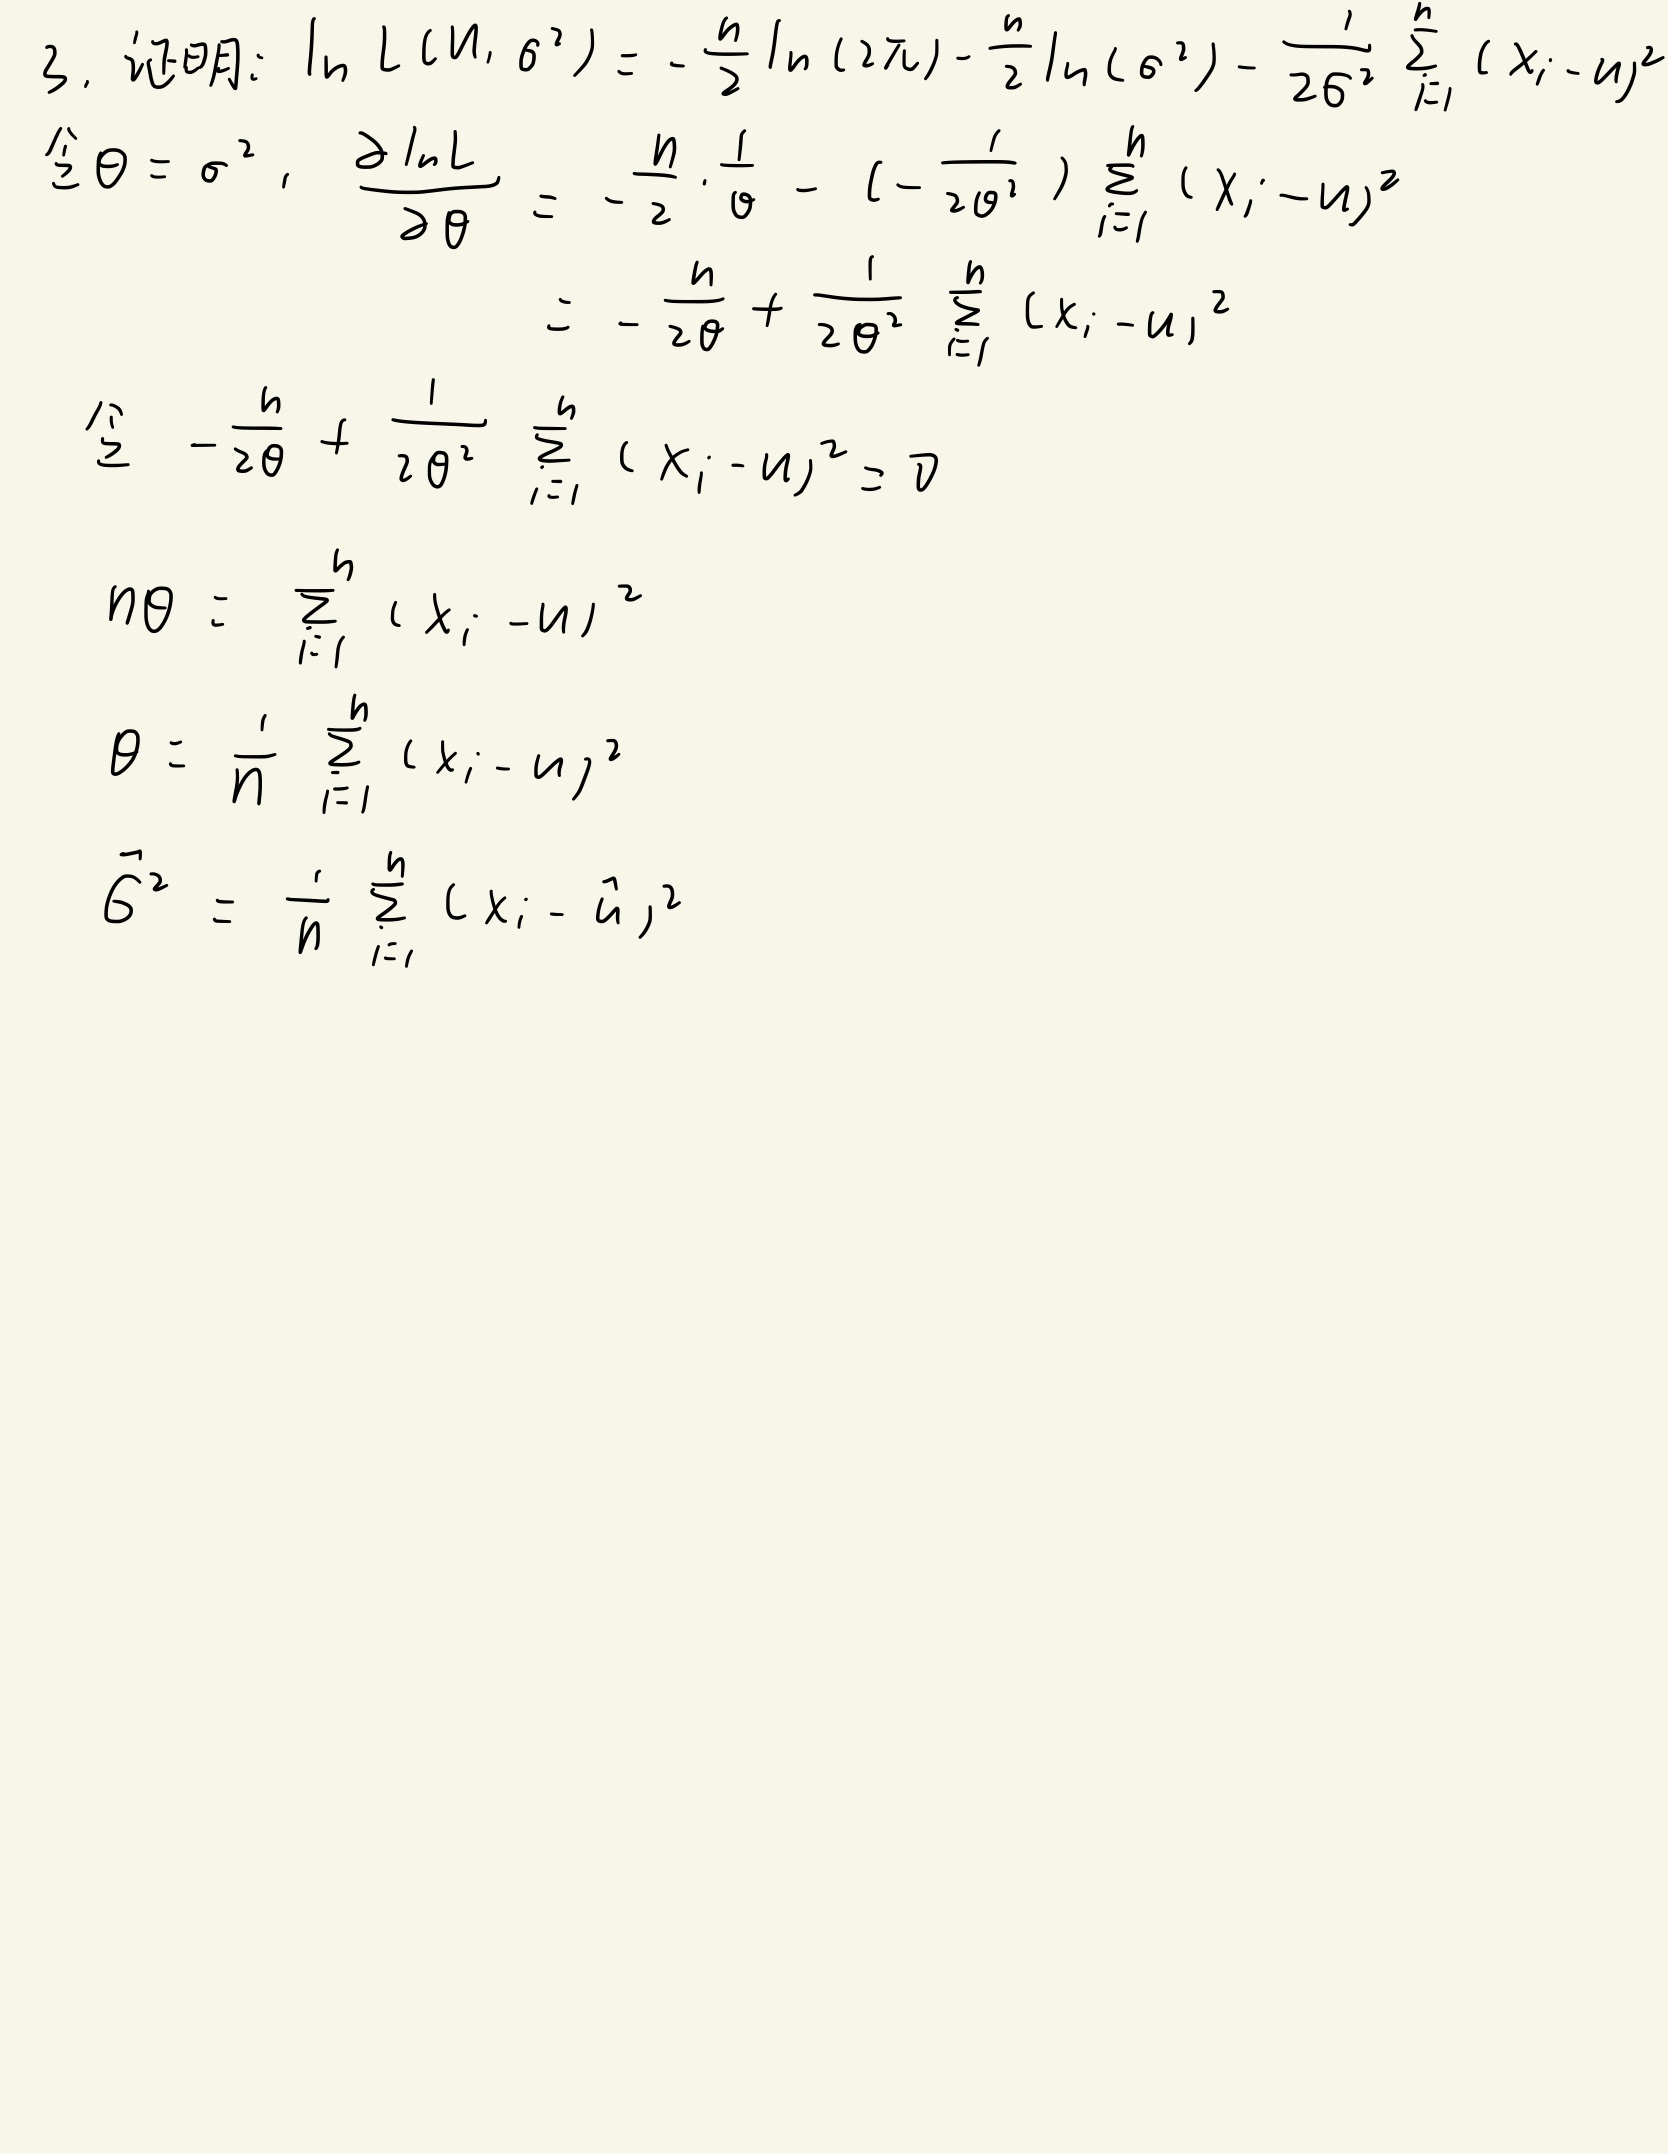

Iter 200, loss = 0.2364
Iter 400, loss = 0.2056
Iter 600, loss = 0.1948
Iter 800, loss = 0.1896
Iter 1000, loss = 0.1868
测试准确率: 0.9000


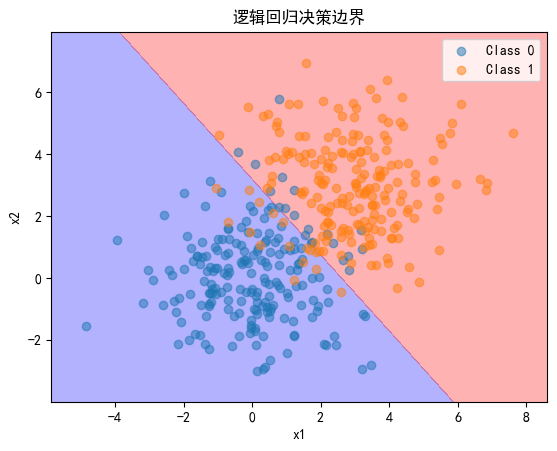

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 生成两类线性可分数据（特征2维）
np.random.seed(42)
n_samples = 200
# 类别0：均值 (0,0)，协方差 [[2,0],[0,2]]
X0 = np.random.randn(n_samples, 2) * 1.5 + np.array([0, 0])
y0 = np.zeros(n_samples)
# 类别1：均值 (3,3)，协方差 [[2,0],[0,2]]
X1 = np.random.randn(n_samples, 2) * 1.5 + np.array([3, 3])
y1 = np.ones(n_samples)
X = np.vstack([X0, X1])
y = np.hstack([y0, y1])

# 划分训练集和测试集（训练400，测试100）
indices = np.random.permutation(400)
X_train, y_train = X[indices[:300]], y[indices[:300]]
X_test, y_test = X[indices[300:]], y[indices[300:]]

# Sigmoid函数
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 二元交叉熵损失（平均）
def binary_cross_entropy(y_true, y_pred):
    eps = 1e-8
    return -np.mean(y_true * np.log(y_pred + eps) + (1-y_true) * np.log(1 - y_pred + eps))

# 梯度下降训练
w = np.random.randn(2)
b = 0.0
lr = 0.1
iterations = 1000

for i in range(iterations):
    logits = X_train @ w + b
    probs = sigmoid(logits)
    loss = binary_cross_entropy(y_train, probs)
    
    # 梯度
    grad_w = X_train.T @ (probs - y_train) / len(y_train)
    grad_b = np.mean(probs - y_train)
    
    w -= lr * grad_w
    b -= lr * grad_b
    
    if (i+1) % 200 == 0:
        print(f"Iter {i+1}, loss = {loss:.4f}")

# 测试准确率
logits_test = X_test @ w + b
probs_test = sigmoid(logits_test)
y_pred = (probs_test >= 0.5).astype(int)
accuracy = np.mean(y_pred == y_test)
print(f"测试准确率: {accuracy:.4f}")

# 绘制决策边界
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
probs_grid = sigmoid(grid @ w + b).reshape(xx.shape)
plt.contourf(xx, yy, probs_grid, levels=[0, 0.5, 1], alpha=0.3, colors=['blue', 'red'])
plt.scatter(X0[:,0], X0[:,1], label='Class 0', alpha=0.5)
plt.scatter(X1[:,0], X1[:,1], label='Class 1', alpha=0.5)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('逻辑回归决策边界')
plt.legend()
plt.show()